# Data Collection and Preparation - Health Emergencies Preparedness and Response Program (HEPR)

This notebook is a template workflow to collect data and prepare the main data to perform a baseline physical accessibility analysis to health facilities. It uses various tools developed by the World Bank's Geospatial Operations Support Team (GOST).

This notebook focuses on a raster-based implementation of market access, using the motorized Global Friction Surface from the [Malaria Atlas Project](https://malariaatlas.org/project-resources/accessibility-to-healthcare/).
Additionaly, it uses population data from [World Pop](https://hub.worldpop.org/project/categories?id=3) (Unconstrained UN-Adjusted 2020, 1km resolution).

## Data Download Links
- [World Pop Raster](https://data.worldpop.org/GIS/Population/Global_2000_2020_1km/2020/)
- [Friction Surface](https://malariaatlas.org/geoserver/ows?service=CSW&version=2.0.1&request=DirectDownload&ResourceId=Explorer:2020_motorized_travel_time_to_healthcare)

## Setup

Import packages required for the analysis

In [1]:
# System
import sys
import os
from os.path import join, expanduser
from pathlib import Path
# Avoid warnings to pop up
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Visualization tools
# import folium as flm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from rasterio.plot import plotting_extent
from rasterio.plot import show
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns


In [3]:
# Processing 
import numpy as np
import geopandas as gpd
import pandas as pd
from gadm import GADMDownloader

# Raster
import rasterio as rio
from rasterio.features import shapes
from shapely.geometry import box
from rasterio.features import geometry_mask
from rasterstats import zonal_stats
from shapely.geometry import Polygon, box, Point
import skimage.graph as graph

# Graph
import pickle
import networkx as nx
import osmnx as ox

# for facebook data
from pyquadkey2 import quadkey

In [4]:
# Climate/Flood
# import xarray as xr

In [5]:
# Define your path to the Repositories

sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'gostrocks', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTNets_Raster', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTnets'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOST_Urban', 'src', 'GOST_Urban'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'health-equity-diagnostics', 'src', 'modules'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'INFRA_SAP'))

import GOSTnets as gn
from GOSTnets.load_osm import *
import GOSTRocks.rasterMisc as rMisc
from GOSTRocks.misc import get_utm
import GOSTNetsRaster.market_access as ma
import UrbanRaster as urban

from infrasap import aggregator
from infrasap import osm_extractor as osm   

from utils import download_osm_shapefiles

In [6]:
# auto reload
%load_ext autoreload
%autoreload 2

Define below the local folder where you are located

In [7]:
data_dir = join(expanduser("/home/jupyter-wb618081"), 'data')
scratch_dir = join(expanduser("/home/jupyter-wb618081"), 'Health-Access-Metrics')
out_path = join(expanduser("/home/jupyter-wb618081"), 'Health-Access-Metrics', 'Output')

## Data Preparation

### Administrative boundaries

In [8]:
epsg = "EPSG:4326"
epsg_utm = "EPSG:32736"

In [9]:
country = 'Malawi'
iso = 'MWI'
downloader = GADMDownloader(version="4.0")
adm0 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=0)
adm1 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=1)
adm2 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=2)

In [10]:
# iso = 'MWI'
# adm0_path = join(expanduser("R:/"), 'Data', 'GLOBAL/ADMIN', f'Admin0_Polys.shp')
# adm0 = gpd.read_file(adm0_path)
# adm0 = adm0[adm0["ISO3"] == "MWI"].to_crs(4326)

# iso = 'MWI'
# adm2_path = join(expanduser("R:/"), 'Data', 'GLOBAL/ADMIN', f'Admin2_Polys.shp')
# adm2 = gpd.read_file(adm2_path)
# adm2 = adm2[adm2["ISO3"] == "MWI"].to_crs(4326)

### Population (origin)

In [11]:
# wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020/MOSAIC_ppp_prj_2020', f'ppp_prj_2020_{iso}.tif') # Download from link above
wp_path = join(data_dir, f'ppp_2020_1km_Aggregated.tif') # Download from link above

pop_surf = rio.open(wp_path)

### Health Facilities (destinations)

In [14]:
hf_path = join(data_dir,'MWI','HF_Malawi.xlsx')
df_hf = pd.read_excel(hf_path)

display('The following categories and numbers of Health Facilities are considered to perform the analysis: ')
display(df_hf["Facility Type"].value_counts())

# Consider all health facilities and hospitals

df_hf_hosp = df_hf.loc[df_hf['Facility Type'] == "Hospital"]

'The following categories and numbers of Health Facilities are considered to perform the analysis: '

Facility Type
Outreach          5090
Village Clinic    3542
Health Centre      542
Health Post        152
Dispensary          87
Hospital            85
Name: count, dtype: int64

In [15]:
# Convert from pandas.Dataframe to Geopandas.dataframe

geodf_hf = gpd.GeoDataFrame(
    df_hf, geometry=gpd.points_from_xy(df_hf.Eastings, df_hf.Northings), crs=epsg
)

geodf_hf_hosp = gpd.GeoDataFrame(
    df_hf_hosp, geometry=gpd.points_from_xy(df_hf_hosp.Eastings, df_hf_hosp.Northings), crs=epsg
)

# Clean the geodf
geodf_hf = geodf_hf[['Facility Name', 'Facility Type','District', 'TA', 'geometry']]; geodf_hf.loc[:, 'ID'] = df_hf.index
geodf_hf_hosp = geodf_hf_hosp[['Facility Name', 'Facility Type', 'District', 'TA', 'geometry']]; geodf_hf_hosp.loc[:, 'ID'] = df_hf_hosp.index


Assure correspondence of ADM1 names in Health facilities and official Administrative Units

In [16]:
geodf_hf.rename(columns={'District': 'ADM1', 'TA': 'ADM2'}, inplace=True)
geodf_hf_hosp.rename(columns={'District': 'ADM1', 'TA': 'ADM2'}, inplace=True)
adm1.rename(columns={"NAME_1":"ADM1"}, inplace=True) 

# The following ADM1 are not corresponding
miss_adm1 = np.setdiff1d(np.sort(geodf_hf.ADM1.unique()), np.sort(adm1.ADM1.unique()))
display(miss_adm1)
display(np.setdiff1d(np.sort(adm1.ADM1.unique()), np.sort(geodf_hf.ADM1.unique())))

array(['Mzimba North', 'Mzimba South'], dtype=object)

array(['Mzimba'], dtype=object)

In [17]:
for adm in miss_adm1:
    for idx in (geodf_hf[geodf_hf.ADM1 == adm].index):
            geodf_hf.loc[idx, 'ADM1'] = 'Mzimba'

    for idx_hosp in (geodf_hf_hosp[geodf_hf_hosp.ADM1 == adm].index):
            geodf_hf_hosp.loc[idx_hosp, 'ADM1'] = 'Mzimba'

### Flood

Here, we import Fathom flood data (.tif) of fluvial floods with different return periods. \
This data represent and mimic the climate impact on infrastructure and the disruption of the accessibility to health facilities.  

In [77]:
# Import multiple rasterio .tif file as a dictionary
# Keys are return periods
# Values are rasterio arrays

# inland waters and oceans: 999
# not-flooded areas: -9999 (Fluvial)
# not-flooded areas: 0 (Pluvial)
# Other values represent the flood depth (in m)

flood_fluvial_path = join(data_dir, iso,'FLOOD_SSBN','fluvial_undefended')
flood_pluvial_path = join(data_dir, iso,'FLOOD_SSBN','pluvial')

files=os.listdir(flood_fluvial_path)
flood_dict_fluvial = {}
for file in files:
    key = file.split('_')[1].split('.')[0]
    value = rio.open(join(flood_fluvial_path,file)) #.read(1)
    flood_dict_fluvial[key] = value

files=os.listdir(flood_pluvial_path)
flood_dict_pluvial = {}
for file in files:
    key = file.split('_')[1].split('.')[0]
    value = rio.open(join(flood_pluvial_path,file)) #.read(1)
    flood_dict_pluvial[key] = value

# Preserve the maximum flood depth
flood_dict = {}
for f,key in enumerate(flood_dict_pluvial.keys()):
    out_flood_path = join(data_dir, iso,'FLOOD_SSBN', 'Fmax_' + key)
    if os.path.isfile(out_flood_path):
        value = rio.open(out_flood_path) 
        flood_dict[key] = value
    else:
        out_meta = flood_dict_pluvial[key].meta
        flood_max = np.fmax(flood_dict_fluvial[key].read(1),flood_dict_pluvial[key].read(1))
        flood_dict[key] = flood_max
        # flood_dict[key][flood_dict[key] == 0] = -999
        # Write the output raster
        out_flood_path = join(data_dir, iso,'FLOOD_SSBN', 'Fmax_' + key)
        with rio.open(out_flood_path, 'w', **out_meta) as dst:
            dst.write(flood_max, 1)
        # Read the output raster
        value = rio.open(out_flood_path) 
        flood_dict[key] = value

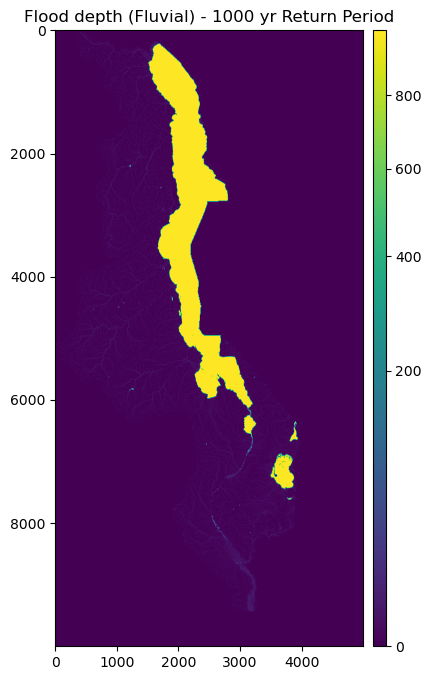

In [75]:
rp = "1in1000"
fig, ax = plt.subplots(figsize=(6,8))
ax.set_title("Flood depth (Fluvial) - {} yr Return Period".format(rp.split('in')[1]), fontsize=12, horizontalalignment='center')
im = ax.imshow(flood_dict[rp].read(1), norm=colors.PowerNorm(gamma=0.5), cmap='viridis')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')

### Friction Surface

Process the travel cost surface from the Malaria Atlas Project, clip the raster to our region of interest.

In [19]:
# # Only the first time, clip the travel friction surface to the country of interest

# gfs_path = join(expanduser("R:/"), 'Data', 'GLOBAL/INFRA/FRICTION_2020', '2020_motorized_friction_surface.geotiff') # Download from link above
# gfs_rio = rio.open(gfs_path)
# out_travel_surface = join(scratch_dir, 'data', iso, f"travel_surface_motorized_{iso}.tif")
# rMisc.clipRaster(gfs_rio, adm0, out_travel_surface, crop=False)

In [82]:
# Import the clipped friction surface

out_travel_surface = join(out_path, iso, f"travel_surface_motorized_{iso}.tif")
travel_surf = rio.open(out_travel_surface) #.read(1)


In [83]:
print(travel_surf.res)
print(pop_surf.res)

(0.008333333333333333, 0.008333333333333333)
(0.0083333333, 0.0083333333)


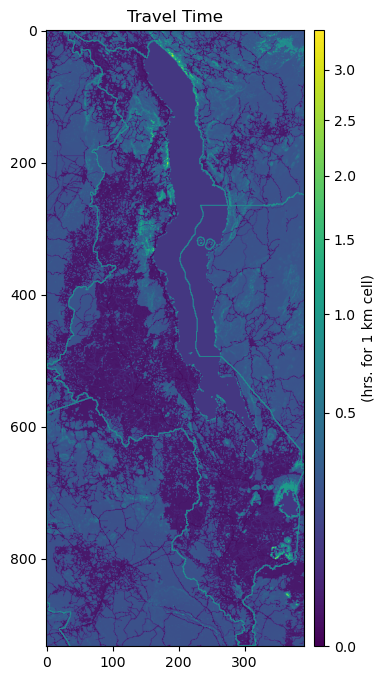

In [84]:
fig, ax = plt.subplots(figsize=(6,8))
ax.set_title("Travel Time", fontsize=12, horizontalalignment='center')
im = ax.imshow(travel_surf.read(1)*1000/60, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.set_label("(hrs. for 1 km cell)")

### Preprocessing



Align the POPULATION & FLOOD raster to the friction surface, ensuring that they have the same extent and resolution.

In [85]:
# If the Standardized data are already present, skip, else generate them

def checkDir(out_path):
    if not os.path.exists(out_path):
        os.makedirs(out_path)

out_pop_surface_std = join(out_path, iso, "WP_2020_1km_STD.tif")
if not os.path.isfile(out_pop_surface_std):
    rMisc.standardizeInputRasters(pop_surf, travel_surf, out_pop_surface_std, resampling_type="nearest")

checkDir(join(scratch_dir, 'data', iso, 'flood'))

for f,key in enumerate(flood_dict.keys()):
    out_flood_std = join(out_path, iso, 'flood', "STD_" + files[f])
    if os.path.isfile(out_flood_std):
        None
    else:
        rMisc.standardizeInputRasters(flood_dict[key], travel_surf, out_flood_std, resampling_type="nearest")

Correct the Flood raster extension, ensuring that lands are not covered by inland and open waters

In [24]:


# land = join(data_dir, "data", iso, "geoBoundaries", "geoBoundaries"+iso+"-ADM1_simplified.shp")

# # Mask the raster with the polygon, using inverse to keep the outside
# r_masked = mask(flood_dict[key], as(pol, "Spatial"), inverse = T )
# # Replace NaN values with 0 in the masked raster
# # r_masked[is.na(r_masked[])] = 0

# # Mask the raster with the polygon
# with rasterio.open('example.tif') as src:
#     out_image, out_transform = mask(src, gdf.geometry, invert=True, nodata=np.nan)
#     masked = out_image[0]

# # Function to fill NaNs with the average of bordering cells, excluding a specific value
# def fill_nan_with_neighboring_average(arr, exclude_value=-999):
#     # Create a kernel to look at all neighboring cells
#     kernel = np.ones((3, 3))
#     kernel[1, 1] = 0  # Do not include the cell itself

#     # Identify cells with value to exclude
#     exclude_mask = (arr == exclude_value)

#     # Replace -999 with np.nan temporarily for mean calculation
#     arr_temp = arr.copy()
#     arr_temp[exclude_mask] = np.nan

#     # Calculate sum and count of neighbors using convolution
#     neighbor_sum = convolve2d(np.nan_to_num(arr_temp), kernel, mode='same', boundary='fill', fillvalue=np.nan)
#     neighbor_count = convolve2d(~np.isnan(arr_temp), kernel, mode='same', boundary='fill', fillvalue=0)

#     # Calculate the mean values
#     neighbor_mean = neighbor_sum / neighbor_count

#     # Fill NaN values in the original array
#     filled_arr = np.where(np.isnan(arr), neighbor_mean, arr)

#     # Ensure the original -999 values are preserved
#     filled_arr[exclude_mask] = exclude_value

#     return filled_arr

# # Fill NaN values
# filled = fill_nan_with_neighboring_average(masked)

### Origins

Prepare a standard grid (pandas.Dataframe) using each cell from the 1km World Pop raster.

In [32]:
pop_surf = rio.open(out_pop_surface_std)
pop = pop_surf.read(1, masked=False)

(32.67083333333333, -9.3625)

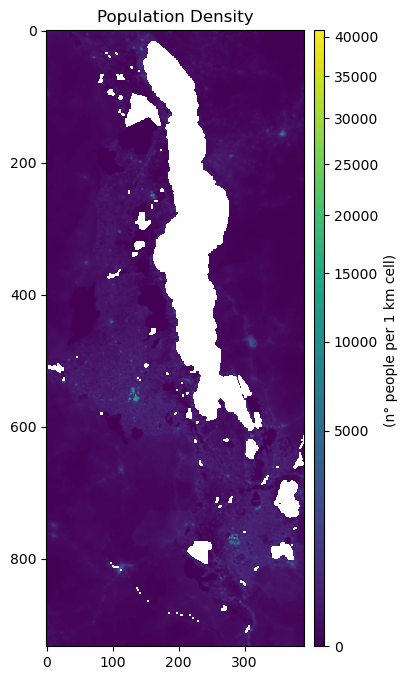

In [33]:
pop_copy = pop.copy()
pop_copy[pop_copy==0] = np.nan

fig, ax = plt.subplots(figsize=(6,8))
ax.set_title("Population Density", fontsize=12, horizontalalignment='center')
im = ax.imshow(pop_copy, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.set_label("(n° people per 1 km cell) ")

pop_surf.xy(0,0)

In [96]:
# Create a population df from population surface 
indices = list(np.ndindex(pop.shape))
xys = [Point(pop_surf.xy(ind[0], ind[1])) for ind in indices]
res_df = pd.DataFrame({
    'spatial_index': indices,
    'xy': xys,
    'pop': pop.flatten()
})
res_df['pointid'] = res_df.index
res_df

,spatial_index,xy,pop,pointid
0,"(0, 0)",POINT (32.67083333333333 -9.3625),67.614548,0
1,"(0, 1)",POINT (32.67916666666666 -9.3625),70.830971,1
2,"(0, 2)",POINT (32.68749999999999 -9.3625),96.481911,2
3,"(0, 3)",POINT (32.695833333333326 -9.3625),111.579651,3
4,"(0, 4)",POINT (32.70416666666666 -9.3625),161.928329,4
...,...,...,...,...
363865,"(932, 385)",POINT (35.879166666666656 -17.129166666666666),32.535667,363865
363866,"(932, 386)",POINT (35.88749999999999 -17.129166666666666),24.958359,363866
363867,"(932, 387)",POINT (35.89583333333332 -17.129166666666666),14.960836,363867
363868,"(932, 388)",POINT (35.904166666666654 -17.129166666666666),14.153514,363868


## Flood impact on Health facilities

For every Standardized Flood layer (Return Period), extract Flood Depth on Health Facilities location

In [36]:
# Import multiple rasterio .tif file as a dictionary
# Keys are return periods
# Values are rasterio arrays

import os 

flood_path = join(scratch_dir, 'data', iso, 'flood')
files=os.listdir(flood_path)

flood_dict = {}
for file in files:
    key = file.split('_')[2].split('.')[0]
    value = rio.open(join(flood_path,file)) #.read(1)
    flood_dict[key] = value

display(flood_dict["1in10"].read_crs())

CRS.from_epsg(4326)

In [37]:
# Extract flood depth at every facility location

for key in flood_dict.keys():
    coords = [(x,y) for x, y in zip(geodf_hf_hosp.geometry.x, geodf_hf_hosp.geometry.y)]
    geodf_hf_hosp[key] = [x[0] for x in flood_dict[key].sample(coords)]

    coords = [(x,y) for x, y in zip(geodf_hf.geometry.x, geodf_hf.geometry.y)]
    geodf_hf[key] = [x[0] for x in flood_dict[key].sample(coords)]


### Summary statistics

For every Flood Scenario (RP):
- Number and % of Health facilities disrupted by Facility Type
- Number and % of Health facilities disrupted by ADM1 Districts

In [38]:
# Reorder Flood Return Periods in geodf columns

def sort_flood_col(gdf, str_start, str_sep):
    # Define str_start and str_sep as the strings that identify the start of column names and the separator with the numerical value
    fd_columns = [col for col in gdf.columns if col.startswith(str_start)]
    non_fd_columns = [col for col in gdf.columns if not col.startswith(str_start)]
    fd_num = [(int(col.split(str_sep)[1]), col) for col in fd_columns]
    fd_col_sort = [col for _, col in sorted(fd_num)]
    new_column_order = non_fd_columns + fd_col_sort
    # Reorder the DataFrame columns
    gdf = gdf[new_column_order]
    return(gdf)

geodf_hf = sort_flood_col(geodf_hf, "1in", "in")
geodf_hf_hosp = sort_flood_col(geodf_hf_hosp, "1in", "in")

In [39]:
# % of Facilities disrupted, by Facility Type

stats1 = geodf_hf[geodf_hf != 0].groupby("Facility Type").count().drop(columns = ["Facility Name", "ADM1", "ADM2", "geometry"]).rename(columns={'ID': 'Total n°'})
fd_columns = [col for col in stats1.columns if col.startswith("1in")]
for col in fd_columns:
    stats1[col] = (stats1[col]/stats1["Total n°"])*100

stats1[fd_columns] = stats1[fd_columns].round(2)
display(stats1)

,Total n°,1in5,1in10,1in20,1in50,1in75,1in100,1in200,1in250,1in500,1in1000
Facility Type,,,,,,,,,,,
Dispensary,87,3.45,4.60,8.05,8.05,8.05,8.05,8.05,8.05,8.05,8.05
Health Centre,542,2.95,3.69,4.24,5.54,5.90,6.09,6.09,6.27,7.38,7.38
Health Post,152,10.53,11.84,13.16,13.16,13.16,13.16,13.82,14.47,15.13,15.79
Hospital,84,2.38,4.76,4.76,5.95,5.95,5.95,5.95,5.95,8.33,8.33
Outreach,5090,3.95,5.34,6.15,6.76,7.01,7.21,7.58,7.72,7.98,8.45
Village Clinic,3542,3.59,4.71,5.48,6.24,6.30,6.52,7.00,7.26,7.54,7.96


In [40]:
stats1_long = pd.melt(stats1.reset_index().drop(columns = "Total n°"), id_vars="Facility Type", var_name="scen")
scen = stats1_long.scen.unique()

In [41]:
# % of Facilities disrupted, by ADM1 (Districts)

stats2 = geodf_hf[geodf_hf != 0].groupby("ADM1").count().drop(columns = ["Facility Name", "Facility Type", "ADM2", "geometry"]).rename(columns={'ID': 'Total n°'})
fd_columns = [col for col in stats2.columns if col.startswith("1in")]
for col in fd_columns:
    stats2[col] = (stats2[col]/stats2["Total n°"])*100

stats2[fd_columns] = stats2[fd_columns].round(2)

# Merge with ADM1 geometries
stats2 = stats2.merge(adm1[["ADM1", "geometry"]], on='ADM1', how='left').set_index("ADM1")
stats2 =gpd.GeoDataFrame(stats2, geometry=stats2["geometry"], crs="EPSG:4326")
display(stats2)

,Total n°,1in5,1in10,1in20,1in50,1in75,1in100,1in200,1in250,1in500,1in1000,geometry
ADM1,,,,,,,,,,,,
Balaka,320,8.75,9.69,10.62,13.12,13.12,13.75,14.69,15.00,15.62,15.62,"MULTIPOLYGON (((35.07923 -15.30382, 35.07925 -..."
Blantyre,276,1.81,2.17,2.17,2.17,2.17,2.17,2.17,2.17,2.17,2.17,"MULTIPOLYGON (((34.94884 -15.98430, 34.94793 -..."
Chikwawa,290,13.45,15.17,18.97,20.00,20.34,21.72,22.76,22.76,24.14,27.24,"MULTIPOLYGON (((34.92864 -16.64210, 34.92845 -..."
Chiradzulu,156,0.00,0.64,1.28,1.28,1.28,1.28,1.28,1.28,1.92,1.92,"MULTIPOLYGON (((35.32407 -15.91358, 35.32412 -..."
Chitipa,213,1.41,1.41,1.41,1.88,1.88,1.88,1.88,1.88,1.88,1.88,"MULTIPOLYGON (((33.75890 -10.23768, 33.79720 -..."
Dedza,389,2.83,3.86,4.11,4.37,4.37,4.88,5.14,5.14,5.40,5.40,"MULTIPOLYGON (((34.03575 -14.48153, 34.03575 -..."
Dowa,559,0.36,0.36,0.72,1.43,1.43,1.43,1.79,1.79,1.79,2.50,"MULTIPOLYGON (((34.18658 -13.69968, 34.18738 -..."
Karonga,281,17.79,23.49,27.40,29.18,30.25,30.60,30.60,31.32,32.38,32.38,"MULTIPOLYGON (((34.17258 -10.58059, 34.17202 -..."
Kasungu,660,0.76,0.76,0.76,0.76,0.76,0.76,0.76,0.76,0.76,0.76,"MULTIPOLYGON (((33.36169 -13.58856, 33.36145 -..."


### Map HF Impact Results

/tmp/ipykernel_2920408/3866595726.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax0.set_xticklabels(sorted(list(set(scen))))
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


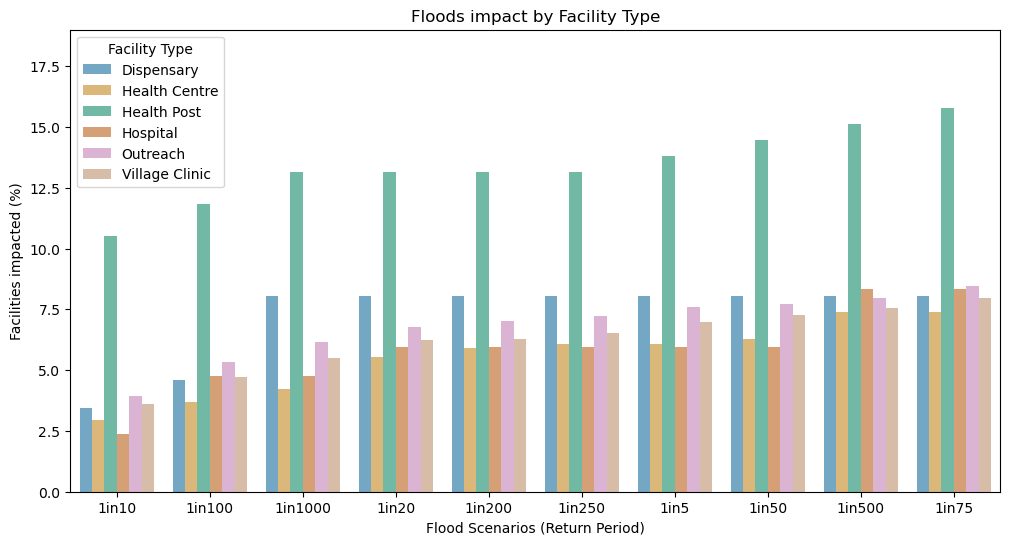

In [42]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Floods impact by Facility Type")
ax0.set_xticklabels(sorted(list(set(scen))))
ax0.set_xlabel("Flood Scenarios (Return Period)")
ax0.set_ylabel("Facilities impacted (%)")
ax0.set_ylim(0,19)
ax0.legend(loc='upper left', fontsize = 10, title = "Facility type")
ax0 = sns.barplot(
    data=stats1_long, hue="Facility Type",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)

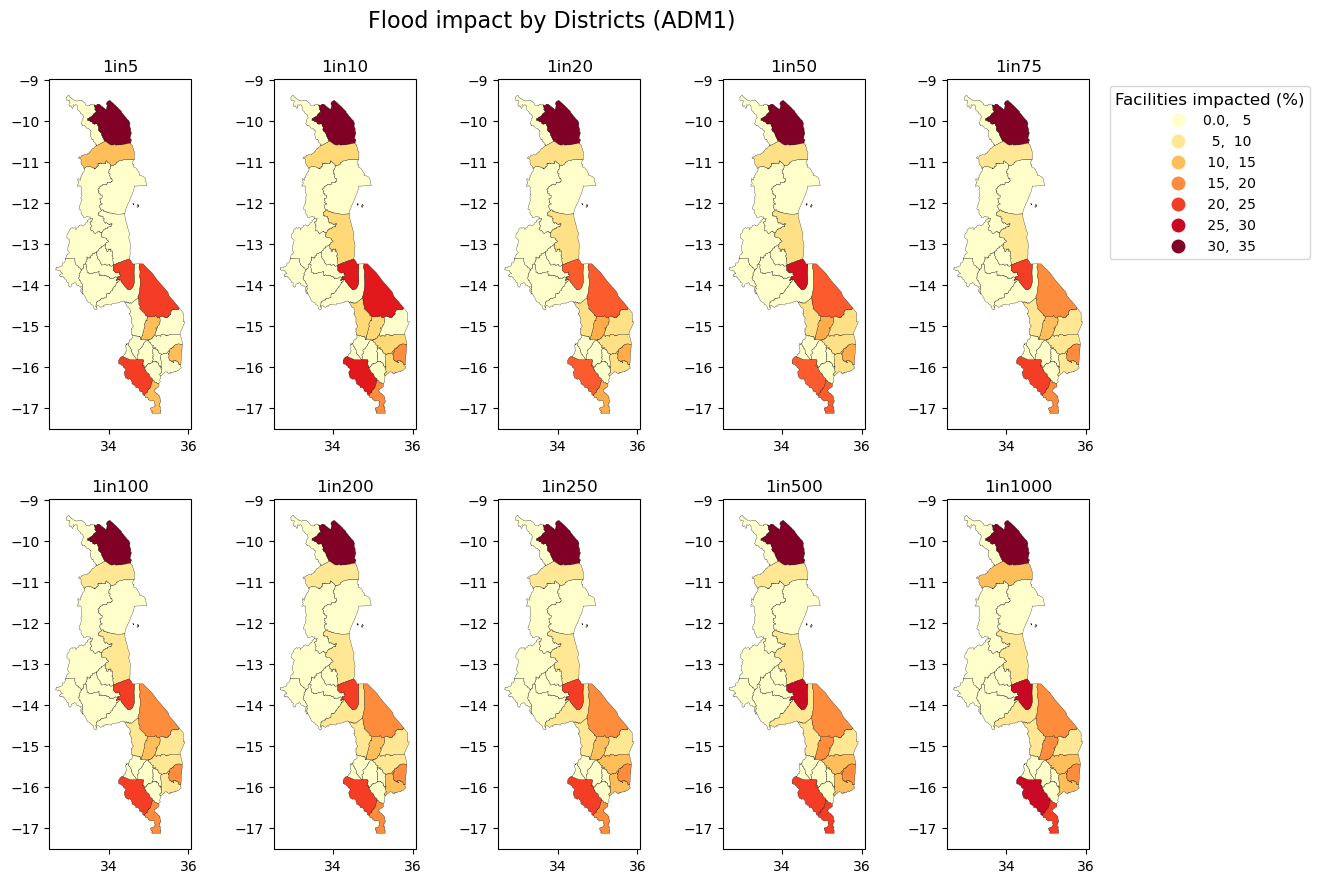

In [48]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (14,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 5)

fig.suptitle("Flood impact by Districts (ADM1)", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

for i, flood in enumerate(scen):
    if i < 5:
        ax = fig.add_subplot(gs[0,i], projection=projection)
    else:
        ax = fig.add_subplot(gs[1,i-5], projection=projection)

    ax.set_title(flood)
    ax.get_xaxis().set_visible(True) # plt.axis('off')
    ax.get_yaxis().set_visible(True)

    if i == 4:
        stats2.plot(
        ax=ax, column=flood, cmap='YlOrRd', legend=True,
        scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
        classification_kwds = {'bins': [5,10,15,20,25,30,35]},
        legend_kwds = {
            'title': "Facilities impacted (%)",
            "loc": "upper right",
            "bbox_to_anchor": (2.6, 1), 
            'fontsize': 10,
            'fmt': "{}",
            'title_fontsize': 12
        }
    )
    else:
        stats2.plot(
        ax=ax, column=flood, cmap='YlOrRd', legend=False,
        scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
        classification_kwds = {'bins': [5,10,15,20,25,30,35]},
        legend_kwds = {
            'title': "Facilities impacted (%)", 
            'fontsize': 10,
            'fmt': "{}",
            'title_fontsize': 12
        }
    )
    
    # ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

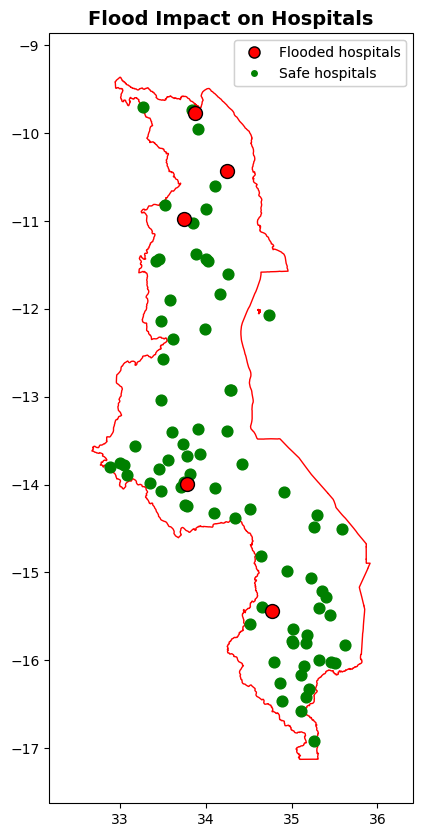

In [49]:
#-- set environment variable CARTOPY_USER_BACKGROUNDS
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

FD = "1in100"

figsize = (12,10)
fig = plt.figure(figsize = (13,10))
projection = ccrs.PlateCarree()
ax1 = fig.add_subplot(1, 2, 1, projection=projection)

fonttitle = {'fontname':'Open Sans','weight':'bold','size':18}
# fig.suptitle("Sectoral severity of needs", size = 16, weight = "bold", y = 0.93)
ax1.set_title("Flood Impact on Hospitals", weight = "bold", size = 14)

ax1.get_xaxis().set_visible(True) # plt.axis('off')
ax1.get_yaxis().set_visible(True)

# ax1 = gdf_adm3_severity.plot(
#     ax=ax, column='Severity', cmap='YlOrRd', legend=True,
#     alpha=1, linewidth=0.2, edgecolor='black', 
#     # classification_kwds = {'bins': [0,1,2,3,4]}, scheme='user_defined'
#     categorical = True,
#     legend_kwds = {
#         "loc": "upper right",
#         "bbox_to_anchor": (1.42, 1),
#         'title': "Severity index", 
#         'fontsize': 10,
#         'fmt': "{}",
#         'title_fontsize': 12
#     }
# )

flood_geodf_hf_hosp = geodf_hf_hosp[geodf_hf_hosp[FD] > 0]
dry_geodf_hf_hosp = geodf_hf_hosp[geodf_hf_hosp[FD] == 0]

ax1 = adm0.plot(ax=ax1, facecolor="none", edgecolor='red')

ax1 = dry_geodf_hf_hosp.plot(ax=ax1, legend = True,
                         facecolor='green', edgecolor='green', marker = "o", markersize=60, #alpha=0.6,
                         categorical = True,
                         legend_kwds = {
                            "loc": "upper right",
                            "bbox_to_anchor": (1.42, 1),
                            'title': "Flood depth", 
                            'fontsize': 10,
                            'fmt': "{}",
                            'title_fontsize': 12
                        })

ax1 = flood_geodf_hf_hosp.plot(ax=ax1, legend = True,
                         facecolor='red', edgecolor='black', marker = "o", markersize=100, #alpha=0.6,
                         categorical = True,
                         legend_kwds = {
                            "loc": "upper right",
                            "bbox_to_anchor": (1.42, 1),
                            'title': "Flood depth", 
                            'fontsize': 10,
                            'fmt': "{}",
                            'title_fontsize': 12
                        })

minx = adm0.geometry.bounds.minx[0]
maxx = adm0.geometry.bounds.maxx[0]
miny = adm0.geometry.bounds.miny[0]
maxy = adm0.geometry.bounds.maxy[0]

ax1.set_extent([minx-0.5, maxx+0.5, miny-0.5, maxy+0.5])

# ax1.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

# Plot legends for GeoDataFrames
# legend1 = ax1.get_legend()

# Manually create new artists legends
legend1 = ax1.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='black', markersize=8, alpha=1),
                                    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markeredgecolor='white',markersize=6, alpha=1)],
                        labels=['Flooded hospitals', 'Safe hospitals'], loc="upper right")

# Combine legends
ax1.add_artist(legend1)
# ax1.add_artist(legend1plus)

# txt = "Severity"
# txt2 = "Fatalities as reported from the ACLED dataset (2010-2024)"
# plt.figtext(0.15, 0.07, txt, wrap=True, horizontalalignment='left', fontsize=10)
# plt.figtext(0.58, 0.07, txt2, wrap=True, horizontalalignment='left', fontsize=10)
# plt.savefig("Flood Impact on Health facilities - Malawi.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

### Flood impact on Friction Surface

We consider different degrees of accessibility/mobility disruption according to different flood depth (FD) levels

- If the FD is less than 0.3 meters, than accessibility is preserved but signifcantly impacted (slowered)
- If the FD is higher than 0.3 meters, than mobility is interrupted on that specific pathway 

In [50]:
# Create weights for the Friction Surface
# If water level is less than 30 cm, accessibility is halved (travel time doubles)
# If water level is more than 30 cm, accessibility is disrupted (travel time *100)

flood_dict_fd = flood_dict.copy()

for key in flood_dict_fd.keys():
    
    flood_dict_fd[key] = flood_dict_fd[key].read(1)     # Need to explicitly open the rasterio within the dictionary to compute weights

    flood_dict_fd[key][(flood_dict[key].read(1) <= 0) | (flood_dict[key].read(1) == 999)] = 1
    flood_dict_fd[key][(flood_dict[key].read(1) > 0) & (flood_dict[key].read(1) < 0.3)] = 2
    flood_dict_fd[key][(flood_dict[key].read(1) >= 0.3) & (flood_dict[key].read(1) < 999)] = 100

    # Check flood weight values
    print(np.unique(flood_dict_fd[key]))

[  1.   2. 100.]
[  1.   2. 100.]
[  1.   2. 100.]
[  1.   2. 100.]
[  1.   2. 100.]
[  1.   2. 100.]
[  1.   2. 100.]
[  1.   2. 100.]
[  1.   2. 100.]
[  1.   2. 100.]


Create new Friction Surface that accounts for Floods disruption 

In [51]:
# Weight the Friction Surface with the discrete flood depth array

travel_surf_flood = dict()
for key in flood_dict_fd.keys():
    travel_surf_flood[key] = travel_surf.read(1) * flood_dict_fd[key]


# Don't know why I did the following:

In [39]:
# # Export the new modified Friction Surface (needed for the computation of travel time) to .tif object
 
# profile = travel_surf.profile.copy()

# for key in flood_dict_fd.keys():
#     outfile = join(scratch_dir, 'data', iso, 'travel_surface_motorized_MWI_' + key + '.tif')
#     new_travel_surface = rio.open(outfile, 'w', **profile)
#     new_travel_surface.write(travel_surf_flood[key], 1)
#     new_travel_surface.close()

# # Import the Flood Friction Surface 
# flood_path = join(scratch_dir, 'data', iso, 'flood')
# files=os.listdir(flood_path)

# travel_surf_flood = {}
# for key in flood_dict_fd.keys():
#     file = join(scratch_dir, 'data', iso, 'travel_surface_motorized_MWI_' + key + '.tif')
#     key = file.split('_')[4].split('.')[0]
#     value = rio.open(file) #.read(1)
#     travel_surf_flood[key] = value

Create an MCP graph object from the flooded friction surfaces.

In [64]:
# convert friction surface to traversal time (lazily). Original data are minutes to travel 1 m:
# We convert it to minutes to cross the cell (1000m). This could be revised

inG_data = dict()
inG_data["baseline"] = travel_surf.read(1) * 1000
for key in travel_surf_flood.keys():
    inG_data[key] = travel_surf_flood[key] * 1000

# Correct no data values. Not needed but good to check
# inG_data[inG_data < 0] = 99999999
# inG_data[inG_data < 0] = np.nan

mcp = dict()
mcp["baseline"] = graph.MCP_Geometric(inG_data["baseline"])
for key in inG_data.keys():
    mcp[key] = graph.MCP_Geometric(inG_data[key])

# Check descriptive statistics
print(f"Mean: {np.mean(inG_data['1in5'])}")
print(f"Max: {np.max(inG_data['1in5'])}")
print(f"Min: {np.min(inG_data['1in5'])}")
print(f"Std: {np.std(inG_data['1in5'])}")

Mean: 16.2965145111084
Max: 9718.626953125
Min: 0.5
Std: 141.70745849609375


## Data analysis

**Indicators of interest**

Percentage of population within 2h of driving to the nearest primary care facility (population level, and by SES quintile). \
Percentage of population within 2h of driving to the nearest district hospital (population, and by SES quintile). \
Percentage of health facilities with direct access to an all season road. \
Percentage of health facilities within 2km of an all season road.


In [97]:
# Calculate the travel time from each grid-cell to the nearest destination
res_hf = dict()
res_hf_hosp = dict()
res_hf["baseline"] = ma.calculate_travel_time(travel_surf, mcp["baseline"], geodf_hf)[0]
res_hf_hosp["baseline"] = ma.calculate_travel_time(travel_surf, mcp["baseline"], geodf_hf_hosp)[0]
for key in travel_surf_flood.keys():
    res_hf[key] = ma.calculate_travel_time(travel_surf, mcp[key], geodf_hf)[0]
    res_hf_hosp[key] = ma.calculate_travel_time(travel_surf, mcp[key], geodf_hf_hosp)[0]

# Check dimension
display(len(res_hf[key].flatten()), len(geodf_hf_hosp))

# Decide to consider all facilities or Hospitals
res_df.loc[:, 'tt_hf_' + "baseline"] = res_hf["baseline"].flatten()
res_df.loc[:, 'tt_hosp_' + "baseline"] = res_hf_hosp["baseline"].flatten()
for key in travel_surf_flood.keys():
    res_df.loc[:, 'tt_hf_' + key] = res_hf[key].flatten()
    res_df.loc[:, 'tt_hosp_' + key] = res_hf_hosp[key].flatten()

# remove values where pop is 0 or nan
res_df = res_df.loc[res_df['pop']!=0].copy()
res_df = res_df.loc[~(res_df['pop'].isna())].copy()

res_df.loc[:,'xy'] = res_df.loc[:,'xy'].apply(lambda x: Point(x))

res_df.head(2)

363870

85

,spatial_index,xy,pop,pointid,tt_hf_baseline,tt_hosp_baseline,tt_hf_1in50,tt_hosp_1in50,tt_hf_1in200,tt_hosp_1in200,...,tt_hf_1in20,tt_hosp_1in20,tt_hf_1in100,tt_hosp_1in100,tt_hf_1in75,tt_hosp_1in75,tt_hf_1in500,tt_hosp_1in500,tt_hf_1in5,tt_hosp_1in5
0,"(0, 0)",POINT (32.67083333333333 -9.3625),67.614548,0,205.364383,205.364383,205.364383,205.364383,205.364383,205.364383,...,205.364383,205.364383,205.364383,205.364383,205.364383,205.364383,205.364383,205.364383,205.364383,205.364383
1,"(0, 1)",POINT (32.67916666666666 -9.3625),70.830971,1,203.864383,203.864383,203.864383,203.864383,203.864383,203.864383,...,203.864383,203.864383,203.864383,203.864383,203.864383,203.864383,203.864383,203.864383,203.864383,203.864383


Create Geodataframe for the population grid

In [98]:
res_gdf = gpd.GeoDataFrame(res_df, geometry='xy', crs=epsg)
res_gdf.rename(columns={'xy':'geometry'}, inplace=True)
res_gdf.set_geometry('geometry', inplace=True)

# convert travel time from minutes to hours
for col in res_gdf.columns:
    if 'tt_' in col:
        res_gdf.loc[:, col] = res_gdf.loc[:, col] / 60
        
res_gdf.head(2)

,spatial_index,geometry,pop,pointid,tt_hf_baseline,tt_hosp_baseline,tt_hf_1in50,tt_hosp_1in50,tt_hf_1in200,tt_hosp_1in200,...,tt_hf_1in20,tt_hosp_1in20,tt_hf_1in100,tt_hosp_1in100,tt_hf_1in75,tt_hosp_1in75,tt_hf_1in500,tt_hosp_1in500,tt_hf_1in5,tt_hosp_1in5
0,"(0, 0)",POINT (32.67083 -9.36250),67.614548,0,3.42274,3.42274,3.42274,3.42274,3.42274,3.42274,...,3.42274,3.42274,3.42274,3.42274,3.42274,3.42274,3.42274,3.42274,3.42274,3.42274
1,"(0, 1)",POINT (32.67917 -9.36250),70.830971,1,3.39774,3.39774,3.39774,3.39774,3.39774,3.39774,...,3.39774,3.39774,3.39774,3.39774,3.39774,3.39774,3.39774,3.39774,3.39774,3.39774


Save results as raster

In [104]:
# Checking if files are already saved in the folder

for col in res_gdf.columns:

    # Health facilities Travel Time surfaces
    if "tt_hf_baseline" in col:
        file = join(scratch_dir, "data", iso, "tt_hf_min_motorized_friction_" + col.split('_')[2] + ".tif")
        if not os.path.isfile(file):
            print("Saving " + file)
            rMisc.rasterizeDataFrame(
                inD = res_gdf,
                outFile = file,
                idField = col,
                templateRaster = out_travel_surface
                )
    
    if 'tt_hf_1in' in col:
        file = join(scratch_dir, "data", iso, "tt_hf_min_motorized_friction_flood_" + col.split('_')[2] + ".tif")
        if not os.path.isfile(file):
            print("Saving " + file)
            rMisc.rasterizeDataFrame(
                inD = res_gdf,
                outFile = file,
                idField = col,
                templateRaster = out_travel_surface
                )
        else:
            print(file.split('/')[6] + " already present")
    
    # Hospitals Travel Time surfaces 
    if "tt_hosp_baseline" in col:
        file = join(scratch_dir, "data", iso, "tt_hospitals_min_motorized_friction_" + col.split('_')[2] + ".tif")
        if not os.path.isfile(file):
            print("Saving " + file)
            rMisc.rasterizeDataFrame(
                inD = res_gdf,
                outFile = file,
                idField = col,
                templateRaster = out_travel_surface
                )
                        
    if 'tt_hosp_1in' in col:
        file = join(scratch_dir, "data", iso, "tt_hospitals_min_motorized_friction_flood_" + col.split('_')[2] + ".tif")
        if not os.path.isfile(file):
            print("Saving " + file)
            rMisc.rasterizeDataFrame(
                inD = res_gdf,
                outFile = file,
                idField = col,
                templateRaster = out_travel_surface
                )
        else:
            print(file.split('/')[6] + " already present")


tt_hf_min_motorized_friction_flood_1in50.tif already present
tt_hospitals_min_motorized_friction_flood_1in50.tif already present
tt_hf_min_motorized_friction_flood_1in200.tif already present
tt_hospitals_min_motorized_friction_flood_1in200.tif already present
tt_hf_min_motorized_friction_flood_1in1000.tif already present
tt_hospitals_min_motorized_friction_flood_1in1000.tif already present
tt_hf_min_motorized_friction_flood_1in250.tif already present
tt_hospitals_min_motorized_friction_flood_1in250.tif already present
tt_hf_min_motorized_friction_flood_1in10.tif already present
tt_hospitals_min_motorized_friction_flood_1in10.tif already present
tt_hf_min_motorized_friction_flood_1in20.tif already present
tt_hospitals_min_motorized_friction_flood_1in20.tif already present
tt_hf_min_motorized_friction_flood_1in100.tif already present
tt_hospitals_min_motorized_friction_flood_1in100.tif already present
tt_hf_min_motorized_friction_flood_1in75.tif already present
tt_hospitals_min_motorized

### Map Travel Time Results

In [113]:
# Baseline and Flood scenarios
flood_path = join(scratch_dir, 'data', iso)
files=os.listdir(flood_path)

tt_rio_hf = {}
tt_rio_hosp = {}
for file in files:
    if 'tt_hf' in file and 'baseline' in file:
        key = file.split('_')[5].split('.')[0]
        value = rio.open(join(flood_path,file)) #.read(1)
        tt_rio_hf[key] = value        
    if 'tt_hf' in file and 'flood' in file:
        key = file.split('_')[6].split('.')[0]
        value = rio.open(join(flood_path,file)) #.read(1)
        tt_rio_hf[key] = value

    if 'tt_hospitals' in file and 'baseline' in file:
        key = file.split('_')[5].split('.')[0]
        value = rio.open(join(flood_path,file)) #.read(1)
        tt_rio_hosp[key] = value        
    if 'tt_hospitals' in file and 'flood' in file:
        key = file.split('_')[6].split('.')[0]
        value = rio.open(join(flood_path,file)) #.read(1)
        tt_rio_hosp[key] = value


Text(0.12, 0.07, 'Riverine flood extent and intensity estimated from FATHOM v2 data (2019)')

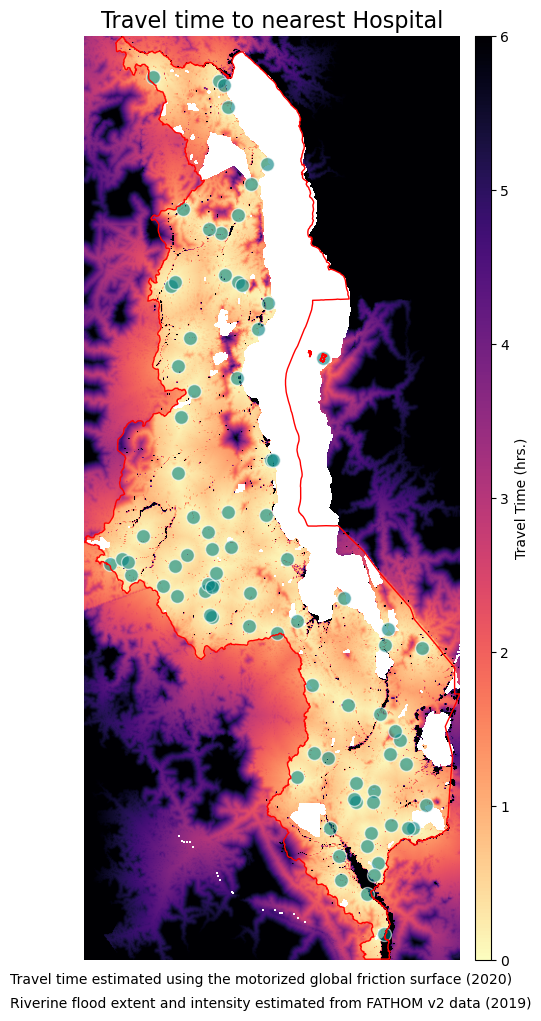

In [69]:
# Single Scenario Plot

figsize = (7, 12)
fig, ax = plt.subplots(1, 1,  figsize = figsize)
ax.set_title("Travel time to nearest Hospital", fontsize=16, horizontalalignment='center')
plt.axis('off')
ext = plotting_extent(tt_rio_hosp["1in100"])
im = ax.imshow(tt_rio_hosp["1in100"].read(1), vmin=0, vmax=6, cmap='magma_r', extent=ext)
geodf_hf_hosp.plot(ax=ax, facecolor='teal', edgecolor='white', markersize=100, alpha=0.6)
adm0.plot(ax=ax, facecolor="none", edgecolor='red')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.set_label("Travel Time (hrs.)")
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs='EPSG:4326', zorder=-1)
txt= "Travel time estimated using the motorized global friction surface (2020)"
txt2 = "Riverine flood extent and intensity estimated from FATHOM v2 data (2019)"
plt.figtext(0.12, 0.09, txt, wrap=True, horizontalalignment='left', fontsize=10)
plt.figtext(0.12, 0.07, txt2, wrap=True, horizontalalignment='left', fontsize=10)
# plt.savefig("travel-time-friction_flood100.png", dpi=300, bbox_inches='tight', facecolor='white')

Text(0.12, 0.05, 'Riverine flood extent and intensity estimated from FATHOM v2 data (2019)')

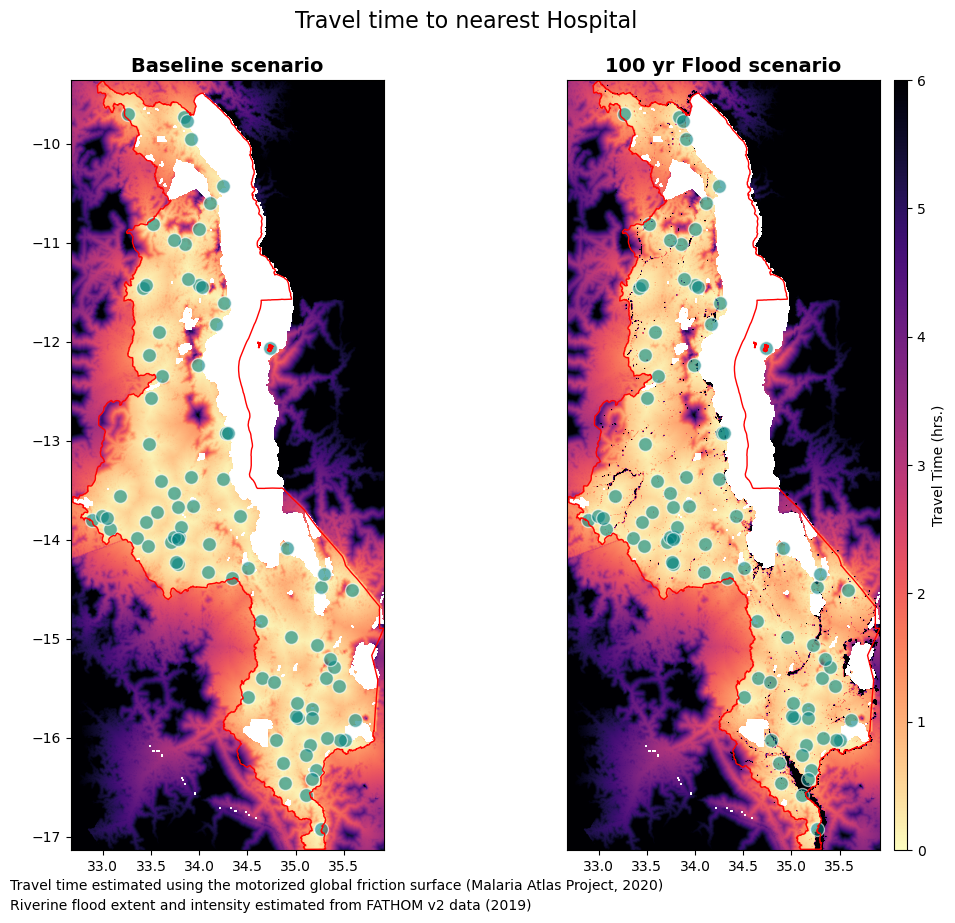

In [115]:
# Multiple Scenario plot

figsize = (12,10)
fig, ax = plt.subplots(1, 2,  figsize = figsize)

fonttitle = {'weight':'bold','size':14}

fig.suptitle("Travel time to nearest Hospital", size = 16, y = 0.95)
ax[0].set_title("Baseline scenario", fontdict=fonttitle)
ax[0].get_xaxis().set_visible(True) # plt.axis('off')
ax[0].get_yaxis().set_visible(True)

ax[1].set_title("100 yr Flood scenario", fontdict=fonttitle)
ax[1].get_xaxis().set_visible(True) # plt.axis('off')
ax[1].get_yaxis().set_visible(False)

ext = plotting_extent(tt_rio_hosp['baseline'])
im = ax[0].imshow(tt_rio_hosp['baseline'].read(1), vmin=0, vmax=6, cmap='magma_r', extent=ext)
geodf_hf_hosp.plot(ax=ax[0], facecolor='teal', edgecolor='white', markersize=100, alpha=0.6)
adm0.plot(ax=ax[0], facecolor="none", edgecolor='red')

ext = plotting_extent(tt_rio_hosp["1in1000"])
im1 = ax[1].imshow(tt_rio_hosp["1in100"].read(1), vmin=0, vmax=6, cmap='magma_r', extent=ext)
geodf_hf_hosp.plot(ax=ax[1], facecolor='teal', edgecolor='white', markersize=100, alpha=0.6)
adm0.plot(ax=ax[1], facecolor="none", edgecolor='red')

divider = make_axes_locatable(ax[1])
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im1, cax=cax, orientation='vertical')
cb.set_label("Travel Time (hrs.)")
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs='EPSG:4326', zorder=-1)
txt = "Travel time estimated using the motorized global friction surface (Malaria Atlas Project, 2020)"
txt2 = "Riverine flood extent and intensity estimated from FATHOM v2 data (2019)"
plt.figtext(0.12, 0.07, txt, wrap=True, horizontalalignment='left', fontsize=10)
plt.figtext(0.12, 0.05, txt2, wrap=True, horizontalalignment='left', fontsize=10)

# plt.savefig("Travel time to nearest Hospital - scenario.png", dpi=300, bbox_inches='tight', facecolor='white')

### Summarize population within 2 hours from Health Facilities

In [147]:
pop = pop_surf.read(1, masked=True)

df_pop = pd.DataFrame(zonal_stats(adm1, pop.filled(), affine=pop_surf.transform, stats='sum', nodata=pop_surf.nodata)).rename(columns={'sum':'pop'})
df_pop_hosp = df_pop.copy()

pop_120_hospital = dict()
df_pop_120_hospital = dict()
for key in tt_rio_hosp.keys():
    pop_120_hospital[key] = pop*(tt_rio_hosp[key].read(1)<=2)
    df_pop_120_hospital[key] = pd.DataFrame(zonal_stats(adm1, pop_120_hospital[key].filled(), affine=pop_surf.transform, stats='sum', nodata=pop_surf.nodata)).rename(columns={'sum':'pop_120_hosp_'+key})
    df_pop_hosp = df_pop_hosp.join(df_pop_120_hospital[key])
    df_pop_hosp.loc[:, "hosp_pct_"+key] = df_pop_hosp.loc[:, "pop_120_hosp_"+key]/df_pop_hosp.loc[:, "pop"]
    res = adm1.join(df_pop_hosp)

res.head(2)

,ID_0,COUNTRY,ID_1,ADM1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,...,pop_120_hosp_1in20,hosp_pct_1in20,pop_120_hosp_1in250,hosp_pct_1in250,pop_120_hosp_1in10,hosp_pct_1in10,pop_120_hosp_1in200,hosp_pct_1in200,pop_120_hosp_1in500,hosp_pct_1in500
0,MWI,Malawi,MWI.1_1,Balaka,,,District,District,,MW.BA,...,4.102606e+05,0.987172,4.075951e+05,0.980759,4.103244e+05,0.987326,407678.625,0.980960,407246.75,0.979920
1,MWI,Malawi,MWI.2_1,Blantyre,,,District,District,,MW.BL,...,1.289037e+06,0.998579,1.287708e+06,0.997549,1.289727e+06,0.999113,1288013.875,0.997786,1287465.00,0.997361


In [148]:
print(f"Summary of % of pop. within 2 hr. of hospital \n {res.hosp_pct_baseline.describe()}")
print(f"Summary of % of pop. within 2 hr. of hospital given 100yr RP floods \n {res.hosp_pct_1in100.describe()}")


Summary of % of pop. within 2 hr. of hospital 
 count    28.000000
mean      0.993119
std       0.016497
min       0.924568
25%       0.997240
50%       0.999288
75%       1.000000
max       1.000000
Name: hosp_pct_baseline, dtype: float64
Summary of % of pop. within 2 hr. of hospital given 100yr RP floods 
 count    28.000000
mean      0.968259
std       0.036030
min       0.841632
25%       0.949503
50%       0.983166
75%       0.993599
max       1.000000
Name: hosp_pct_1in100, dtype: float64


### Accessibility Maps (Share of pop.)

Percentage of population within 2 hours of driving to the nearest primary care facility, by District (ADM1).​

<Axes: title={'center': '100 yr Flood scenario'}>

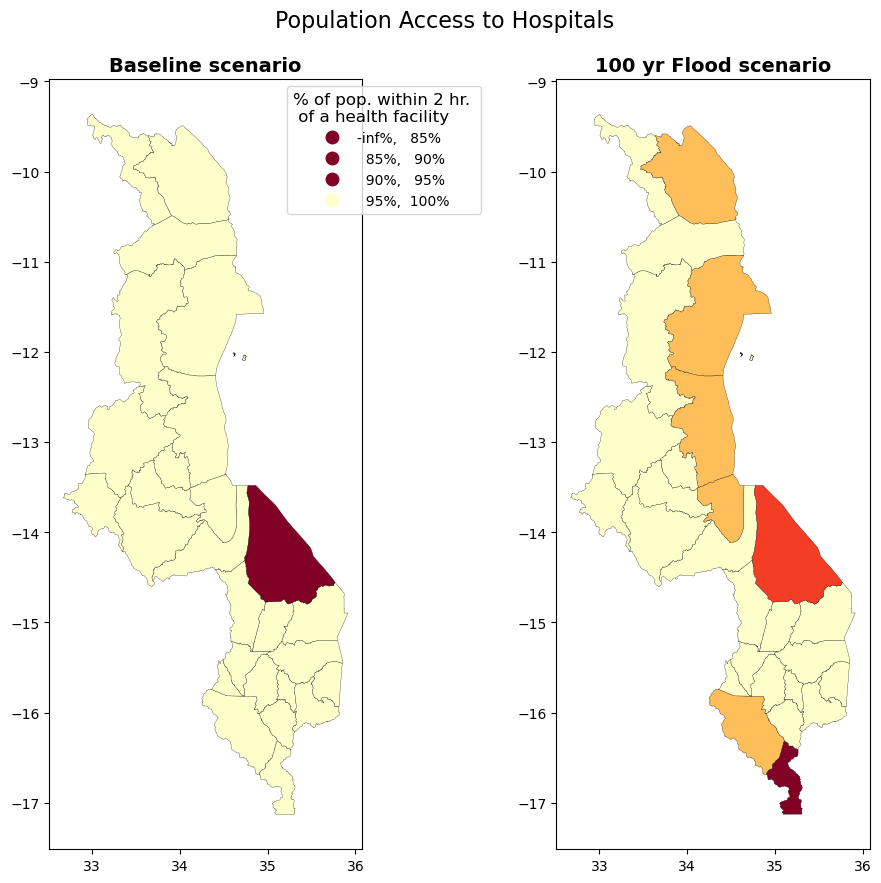

In [76]:
figsize = (12,10)
fig, ax = plt.subplots(1, 2,  figsize = figsize)
fonttitle = {'weight':'bold','size':14}

fig.suptitle("Population Access to Hospitals", size = 16, y = 0.95)
ax[0].set_title("Baseline scenario", fontdict=fonttitle)
ax[0].get_xaxis().set_visible(True) # plt.axis('off')
ax[0].get_yaxis().set_visible(True)

ax[1].set_title("100 yr Flood scenario", fontdict=fonttitle)
ax[1].get_xaxis().set_visible(True) # plt.axis('off')
ax[1].get_yaxis().set_visible(True)

res.plot(
    ax=ax[0], column='hosp_pct_baseline', cmap='YlOrRd_r', legend=True,
    scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
    classification_kwds = {'bins': [0.85,0.9,0.95,1]},
    legend_kwds = {
        'title': "% of pop. within 2 hr. \n of a health facility",
        "loc": "upper right",
        "bbox_to_anchor": (1.4, 1), 
        'fontsize': 10, 
        'fmt': "{:.0%}",
        'title_fontsize': 12
    }
)

res.plot(
    ax=ax[1], column='hosp_pct_1in100', cmap='YlOrRd_r', legend=False,
    scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
    classification_kwds = {'bins': [0.85,0.9,0.95,1]},
    legend_kwds = {
        'title': "% of pop. within 2 hr. \n of a health facility",
        'fontsize': 10,
        'fmt': "{:.0%}",
        'title_fontsize': 12
    }
)

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

### Access to roads

Percentage of Health Facilities having direct access to an all-season road, by district (admin-2 level).​

Assumptions:

- All Health facilities considered are: Hospital, Health Post, Village Clinic, Health Centre, Dispensary and Outreach
- Floods impact all roads except primary and secondary bridges.
- Roads are disrupted if Flood Depth is > 30 cm.
- All-season road defined as primary and secondary or tertiary using the OpenStreetMap classification.
- Direct access defined as being within 100 meters of a road.​

Load OSM roads and define classification 
``` python
{
    'motorway': 'OSMLR level 1',
    'motorway_link': 'OSMLR level 1',
    'trunk': 'OSMLR level 1',
    'trunk_link': 'OSMLR level 1',
    'primary': 'OSMLR level 1',
    'primary_link': 'OSMLR level 1',
    'secondary': 'OSMLR level 2',
    'secondary_link': 'OSMLR level 2',
    'tertiary': 'OSMLR level 2',
    'tertiary_link': 'OSMLR level 2',
    'unclassified': 'OSMLR level 3',
    'unclassified_link': 'OSMLR level 3',
    'residential': 'OSMLR level 3',
    'residential_link': 'OSMLR level 3',
    'track': 'OSMLR level 4',
    'service': 'OSMLR level 4'
}
 ```

In [76]:
# Only for the first time, need to download OSM .shp

# download_osm_shapefiles('africa', 'malawi', Path(join(data_dir, 'data', iso)))

Saving file .............


In [77]:
# Load the Road network

roads = gpd.read_file(join(data_dir, iso, "malawi-latest-free.shp", 'gis_osm_roads_free_1.shp'))
roads = roads.to_crs(epsg)
roads['OSMLR'] = roads['fclass'].map(osm.OSMLR_Classes)
def get_num(x):
    try:
        return(int(x))
    except:
        return(5)
roads['OSMLR_num'] = roads['OSMLR'].apply(lambda x: get_num(str(x)[-1]))


KeyboardInterrupt: 

In [ ]:
# Floods can impact all the roads, except the bridges in primary and second roads

roads_flood = roads[~((roads['bridge'] == "T") & ((roads['OSMLR_num'] == 1) | (roads['OSMLR_num'] == 2)))]
roads_flood.head(2)

In [63]:
# If water level is more than 30 cm, the road is disrupted

flood_dict_road = flood_dict.copy()

mask = dict()
transf = dict()
for key in list(scen):
    
    flood_dict_road[key] = flood_dict_road[key].read(1)     # Need to explicitly open the rasterio within the dictionary to compute weights
    transf[key] = flood_dict[key].transform

    mask[key] = (flood_dict_road[key] >= 0.3)

In [64]:
# Create Polygons only from those cells where mask = True 

def raster_cells_to_polygons(mask, transform):
    polygons = []
    for (row, col), value in np.ndenumerate(mask):
            if value:         # Only create polygons where the mask is True
                # Get the coordinates of the top left corner of the cell
                top_left = rio.transform.xy(transform, row, col, offset='ul')
                # Since each cell is a square, calculate the bottom right corner
                bottom_right = rio.transform.xy(transform, row+1, col+1, offset='ul')
                
                # Create a polygon from these coordinates
                polygon = box(top_left[0], bottom_right[1], bottom_right[0], top_left[1])
                polygons.append(polygon)
    return polygons


In [65]:
# Vectorize the flood layers in polygons geometries

flood_poly = dict()
flood_poly_gdf = dict()
for key in mask.keys():
    flood_poly[key] = raster_cells_to_polygons(mask[key], transf[key])
    flood_poly_gdf[key] = gpd.GeoDataFrame(geometry=flood_poly[key], crs=epsg)  # Make sure to set the correct CRS

In [66]:
# Remove from the roads geodf the flooded roads

roads_impact = dict()
for key in mask.keys():
    intersections = gpd.sjoin(roads_flood[["osm_id", "fclass","bridge","geometry","OSMLR"]], flood_poly_gdf[key], how="inner", predicate='intersects')
    intersections.drop_duplicates(subset="osm_id", inplace = True)
    roads_impact[key] = roads.drop(intersections.index)

Baseline scenario

In [67]:
data_health = geodf_hf.copy().to_crs(epsg_utm) #[~(geodf_hf['Facility Type'] == "Outreach")]

## Calculate buffers
roads_100m = roads.copy().to_crs(epsg_utm)
roads_100m['geometry'] = roads_100m['geometry'].apply(lambda x: x.buffer(100))

roads_2km = roads.copy().to_crs(epsg_utm)
roads_2km['geometry'] = roads_2km['geometry'].apply(lambda x: x.buffer(2000))

## Intersect roads and buffer
# roads_1_100m = roads_100m.loc[roads_100m.OSMLR_num<=1].unary_union
roads_2_100m = roads_100m.loc[roads_100m.OSMLR_num<=2].unary_union
# roads_3 = roads.loc[roads.OSMLR_num<=3].unary_union
# roads_4 = roads.loc[roads.OSMLR_num<=4].unary_union

# geodf_hf.loc[:, "bool_1_100m"] = geodf_hf.intersects(roads_1_100m)
data_health.loc[:, "bool_2_100m_baseline"] = data_health.intersects(roads_2_100m)
# geodf_hf.loc[:, "bool_3"] = geodf_hf.intersects(roads_3)
# geodf_hf.loc[:, "bool_4"] = geodf_hf.intersects(roads_4)

# roads_1_2km = roads_2km.loc[roads_2km.OSMLR_num<=1].unary_union
roads_2_2km = roads_2km.loc[roads_2km.OSMLR_num<=2].unary_union
# roads_3 = roads.loc[roads.OSMLR_num<=3].unary_union
# roads_4 = roads.loc[roads.OSMLR_num<=4].unary_union

# geodf_hf.loc[:, "bool_1_2km"] = geodf_hf.intersects(roads_1_2km)
data_health.loc[:, "bool_2_2km_baseline"] = data_health.intersects(roads_2_2km)
# geodf_hf.loc[:, "bool_3"] = geodf_hf.intersects(roads_3)
# geodf_hf.loc[:, "bool_4"] = geodf_hf.intersects(roads_4)

data_health = data_health.to_crs(epsg)
adm1 = adm1.to_crs(epsg)
geodf_hf_road_base = gpd.sjoin(data_health, adm1[['geometry']], how='left').drop(columns = "index_right")

## Get percentages
# res_osmlr = facilities[['bool_1_100m','bool_2_100m','bool_1_2km','bool_2_2km','WB_ADM2_CO']].groupby('WB_ADM2_CO').sum()
res_osmlr = geodf_hf_road_base[['bool_2_100m_baseline','bool_2_2km_baseline','ADM1']].groupby('ADM1').sum()
res_count = geodf_hf_road_base[['ADM1','bool_2_100m_baseline']].groupby('ADM1').count().rename(columns={'bool_2_100m_baseline':'count'})
res_osmlr_pct_base = res_osmlr.apply(lambda x: x/res_count['count'])
res_osmlr_pct_base.reset_index(inplace = True)

In [68]:
res_osmlr_pct_base.head(2)

,ADM1,bool_2_100m_baseline,bool_2_2km_baseline
0,Balaka,0.243750,0.568750
1,Blantyre,0.206522,0.623188


Floods scenarios

In [77]:
data_health = geodf_hf[['ADM1', "geometry"]].copy().to_crs(epsg_utm)      # [~(geodf_hf['Facility Type'] == "Outreach")]

for key in roads_impact.keys():

    ## Calculate buffers
    roads_100m = roads_impact[key].copy().to_crs(epsg_utm)
    roads_100m['geometry'] = roads_100m['geometry'].apply(lambda x: x.buffer(100))

    roads_2km = roads_impact[key].copy().to_crs(epsg_utm)
    roads_2km['geometry'] = roads_2km['geometry'].apply(lambda x: x.buffer(2000))

    ## Intersect roads and buffer
    # roads_1_100m = roads_100m.loc[roads_100m.OSMLR_num<=1].unary_union
    roads_2_100m = roads_100m.loc[roads_100m.OSMLR_num<=2].unary_union
    # roads_3 = roads.loc[roads.OSMLR_num<=3].unary_union
    # roads_4 = roads.loc[roads.OSMLR_num<=4].unary_union

    # geodf_hf.loc[:, "bool_1_100m"] = geodf_hf.intersects(roads_1_100m)
    data_health.loc[:, "bool_2_100m_" + key] = data_health.intersects(roads_2_100m)
    # geodf_hf.loc[:, "bool_3"] = geodf_hf.intersects(roads_3)
    # geodf_hf.loc[:, "bool_4"] = geodf_hf.intersects(roads_4)

    # roads_1_2km = roads_2km.loc[roads_2km.OSMLR_num<=1].unary_union
    roads_2_2km = roads_2km.loc[roads_2km.OSMLR_num<=2].unary_union
    # roads_3 = roads.loc[roads.OSMLR_num<=3].unary_union
    # roads_4 = roads.loc[roads.OSMLR_num<=4].unary_union

    # geodf_hf.loc[:, "bool_1_2km"] = geodf_hf.intersects(roads_1_2km)
    data_health.loc[:, "bool_2_2km_" + key] = data_health.intersects(roads_2_2km)
    # geodf_hf.loc[:, "bool_3"] = geodf_hf.intersects(roads_3)
    # geodf_hf.loc[:, "bool_4"] = geodf_hf.intersects(roads_4)

data_health = data_health.to_crs(epsg)
adm1 = adm1.to_crs(epsg)

geodf_hf_road = gpd.sjoin(data_health, adm1[['geometry']], how='left').drop(columns = "index_right")
## Get percentages
# res_osmlr = facilities[['bool_1_100m','bool_2_100m','bool_1_2km','bool_2_2km','WB_ADM2_CO']].groupby('WB_ADM2_CO').sum()
columns = [col for col in geodf_hf_road.columns if col.startswith("bool")]
res_osmlr = geodf_hf_road[columns+['ADM1']].groupby('ADM1').sum()
res_count = geodf_hf_road[["bool_2_100m_"+key,'ADM1']].groupby('ADM1').count().rename(columns={'bool_2_100m_'+key:'count'})
res_osmlr_pct = res_osmlr.apply(lambda x: x/res_count['count'])
res_osmlr_pct.reset_index(inplace = True)
res_osmlr_pct.head(2)

,ADM1,bool_2_100m_1in5,bool_2_2km_1in5,bool_2_100m_1in10,bool_2_2km_1in10,bool_2_100m_1in20,bool_2_2km_1in20,bool_2_100m_1in50,bool_2_2km_1in50,bool_2_100m_1in75,...,bool_2_100m_1in100,bool_2_2km_1in100,bool_2_100m_1in200,bool_2_2km_1in200,bool_2_100m_1in250,bool_2_2km_1in250,bool_2_100m_1in500,bool_2_2km_1in500,bool_2_100m_1in1000,bool_2_2km_1in1000
0,Balaka,0.203125,0.534375,0.184375,0.518750,0.184375,0.518750,0.153125,0.456250,0.153125,...,0.153125,0.456250,0.131250,0.418750,0.131250,0.418750,0.131250,0.418750,0.131250,0.418750
1,Blantyre,0.202899,0.623188,0.202899,0.623188,0.202899,0.623188,0.195652,0.594203,0.195652,...,0.195652,0.594203,0.192029,0.576087,0.192029,0.576087,0.177536,0.550725,0.177536,0.550725
2,Chikwawa,0.206897,0.562069,0.206897,0.558621,0.200000,0.555172,0.200000,0.555172,0.200000,...,0.200000,0.555172,0.200000,0.555172,0.196552,0.541379,0.196552,0.541379,0.179310,0.524138
3,Chiradzulu,0.141026,0.692308,0.141026,0.660256,0.141026,0.660256,0.141026,0.660256,0.134615,...,0.134615,0.621795,0.134615,0.621795,0.134615,0.621795,0.134615,0.621795,0.128205,0.602564
4,Chitipa,0.378505,0.742991,0.378505,0.742991,0.378505,0.733645,0.364486,0.733645,0.364486,...,0.364486,0.733645,0.364486,0.733645,0.364486,0.733645,0.364486,0.733645,0.355140,0.724299
5,Dedza,0.282776,0.676093,0.264781,0.670951,0.264781,0.670951,0.249357,0.660668,0.233933,...,0.233933,0.650386,0.226221,0.647815,0.226221,0.647815,0.226221,0.642674,0.226221,0.634961
6,Dowa,0.175313,0.538462,0.168157,0.520572,0.162791,0.515206,0.155635,0.508050,0.155635,...,0.155635,0.508050,0.155635,0.508050,0.155635,0.508050,0.155635,0.508050,0.150268,0.497317
7,Karonga,0.185053,0.601423,0.177936,0.580071,0.124555,0.551601,0.106762,0.508897,0.106762,...,0.106762,0.508897,0.085409,0.508897,0.085409,0.508897,0.085409,0.508897,0.085409,0.505338
8,Kasungu,0.213636,0.454545,0.206061,0.450000,0.206061,0.450000,0.200000,0.443939,0.200000,...,0.200000,0.443939,0.200000,0.443939,0.200000,0.443939,0.200000,0.443939,0.195455,0.439394
9,Likoma,0.153846,0.615385,0.153846,0.615385,0.153846,0.615385,0.153846,0.615385,0.153846,...,0.153846,0.615385,0.153846,0.615385,0.153846,0.615385,0.153846,0.615385,0.153846,0.615385


In [89]:
geo_res_osmlr_pct_base = gpd.GeoDataFrame(res_osmlr_pct_base, geometry=adm1.geometry, crs=epsg)
geo_res_osmlr_pct = gpd.GeoDataFrame(res_osmlr_pct, geometry=adm1.geometry, crs=epsg)

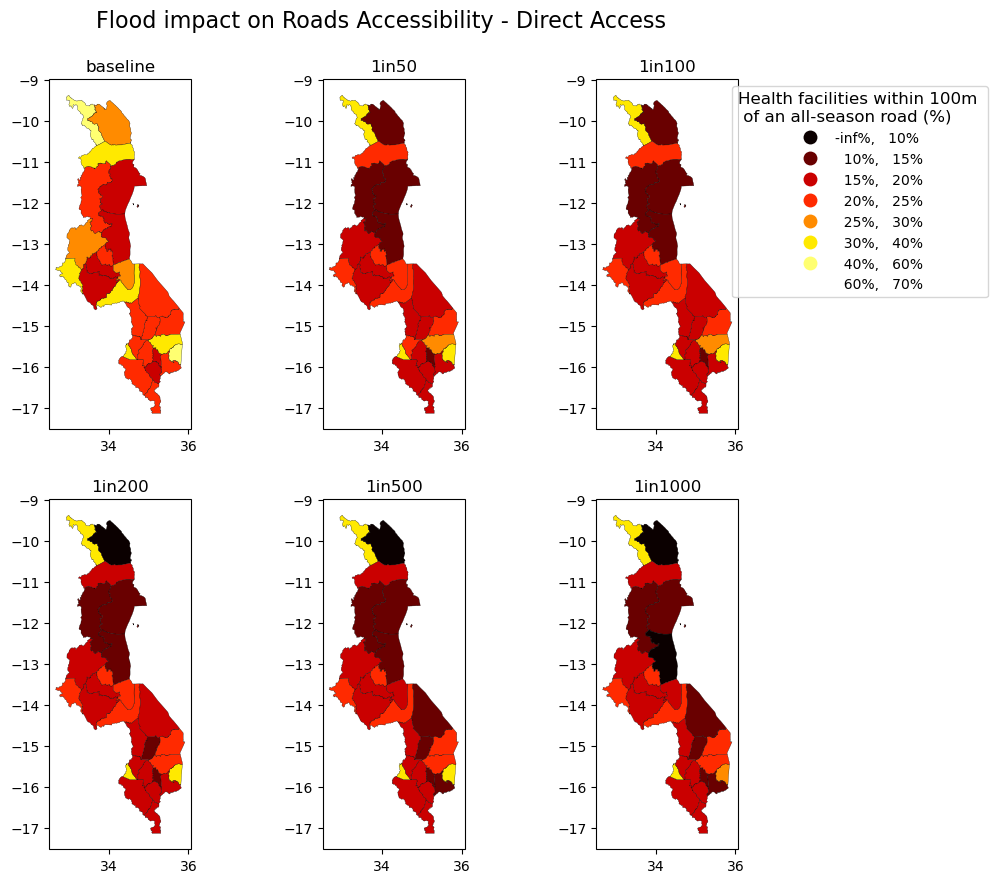

In [123]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (10,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 3)

fig.suptitle("Flood impact on Roads Accessibility - Direct Access", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

scen_toplot = ["baseline", '1in50', '1in100', '1in200', '1in500', '1in1000']
for i, flood in enumerate(scen_toplot):
    if i < 3:
        ax = fig.add_subplot(gs[0,i], projection=projection)
    else:
        ax = fig.add_subplot(gs[1,i-3], projection=projection)

    ax.set_title(flood)
    ax.get_xaxis().set_visible(True) # plt.axis('off')
    ax.get_yaxis().set_visible(True)

    cmap = "hot"
    if i == 0:
        geo_res_osmlr_pct_base.plot(
        ax=ax, column="bool_2_100m_"+flood, cmap=cmap, legend=False,
        scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
        classification_kwds = {'bins': [0.1,0.15,0.2,0.25,0.3,0.4,0.6,0.7]},
        legend_kwds = {
            'title': "Health facilities within \n 100m of an all-season road (%)",
            "loc": "upper right",
            "bbox_to_anchor": (2.7, 1), 
            'fontsize': 10,
            'fmt': "{}",
            'title_fontsize': 12
        }
    )
        
    else:
        if i == 2:
            geo_res_osmlr_pct.plot(
            ax=ax, column="bool_2_100m_"+ flood, cmap=cmap, legend=True,
            scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
            classification_kwds = {'bins': [0.1,0.15,0.2,0.25,0.3,0.4,0.6,0.7]},
            legend_kwds = {
                'title': "Health facilities within 100m \n of an all-season road (%)",
                "loc": "upper right",
                "bbox_to_anchor": (2.8, 1), 
                'fontsize': 10,
                'fmt': "{:.0%}",
                'title_fontsize': 12
            }
        )
        else:
            geo_res_osmlr_pct.plot(
            ax=ax, column='bool_2_100m_'+flood, cmap=cmap, legend=False,
            scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
            classification_kwds = {'bins': [0.1,0.15,0.2,0.25,0.3,0.4,0.6,0.7]},
            legend_kwds = {
                'title': "Health facilities within 100m \n of an all-season road (%)", 
                'fontsize': 10,
                'fmt': "{}",
                'title_fontsize': 12
            }
        )
    
    # ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

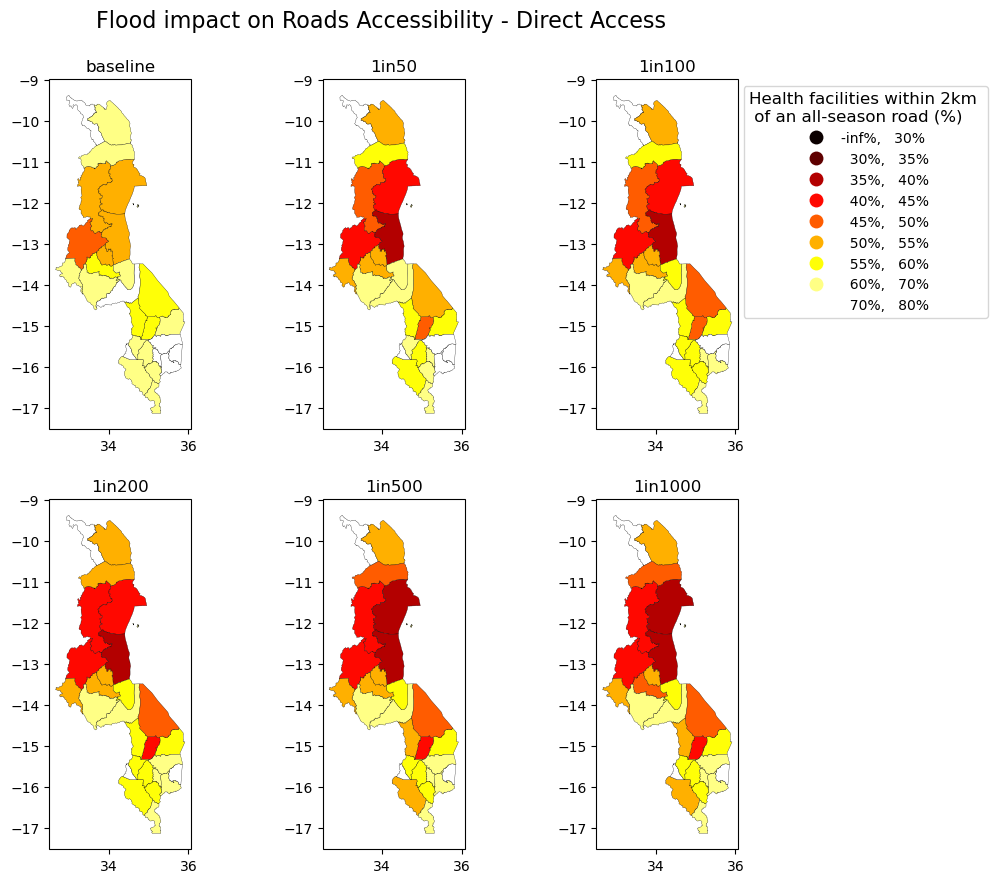

In [121]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (10,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 3)

fig.suptitle("Flood impact on Roads Accessibility - Direct Access", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

scen_toplot = ["baseline", '1in50', '1in100', '1in200', '1in500', '1in1000']
for i, flood in enumerate(scen_toplot):
    if i < 3:
        ax = fig.add_subplot(gs[0,i], projection=projection)
    else:
        ax = fig.add_subplot(gs[1,i-3], projection=projection)

    ax.set_title(flood)
    ax.get_xaxis().set_visible(True) # plt.axis('off')
    ax.get_yaxis().set_visible(True)

    cmap = "hot"
    if i == 0:
        geo_res_osmlr_pct_base.plot(
        ax=ax, column="bool_2_2km_"+flood, cmap=cmap, legend=False,
        scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
        classification_kwds = {'bins': [0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.7,0.8]},
        legend_kwds = {
            'title': "Health facilities within \n 2km of an all-season road (%)",
            "loc": "upper right",
            "bbox_to_anchor": (2.7, 1), 
            'fontsize': 10,
            'fmt': "{}",
            'title_fontsize': 12
        }
    )
        
    else:
        if i == 2:
            geo_res_osmlr_pct.plot(
            ax=ax, column="bool_2_2km_"+ flood, cmap=cmap, legend=True,
            scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
            classification_kwds = {'bins': [0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.7,0.8]},
            legend_kwds = {
                'title': "Health facilities within 2km \n of an all-season road (%)",
                "loc": "upper right",
                "bbox_to_anchor": (2.8, 1), 
                'fontsize': 10,
                'fmt': "{:.0%}",
                'title_fontsize': 12
            }
        )
        else:
            geo_res_osmlr_pct.plot(
            ax=ax, column='bool_2_2km_'+flood, cmap=cmap, legend=False,
            scheme='user_defined', alpha=1, linewidth=0.2, edgecolor='black', 
            classification_kwds = {'bins': [0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.7,0.8]},
            legend_kwds = {
                'title': "Health facilities within 2km \n of an all-season road (%)", 
                'fontsize': 10,
                'fmt': "{}",
                'title_fontsize': 12
            }
        )
    
    # ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

### Access to health disaggregated by wealth quintile

Categorize population grid by wealth quintiles, and then summarize the population with access to health (within 2 hours of health facility or hospital)

Hospitals

In [288]:
# Open Relative Wealth index and Population from Facebook
df_fb_rwi = pd.read_csv(os.path.join(data_dir, iso, 'meta', f'{iso.lower()}_relative_wealth_index.csv'))
geodf_fb = [Point(xy) for xy in zip(df_fb_rwi.longitude, df_fb_rwi.latitude)]
geodf_fb = gpd.GeoDataFrame(df_fb_rwi, crs=epsg, geometry=geodf_fb)
geodf_fb = gpd.sjoin(geodf_fb, adm1[['ADM1','geometry']])

df_fb_pop = pd.read_csv(os.path.join(data_dir, iso, 'meta', f'{iso.lower()}_general_2020.csv'))
df_fb_pop = df_fb_pop.rename(columns={f'{iso.lower()}_general_2020': 'pop_2020'})
    
df_fb_flood_hosp = dict()
for key in tt_rio_hosp.keys():

    # Zonal mean of RWI in tt_rio_hosp cells
    df_fb_flood_hosp[key] = pd.DataFrame(zonal_stats(geodf_fb, tt_rio_hosp[key].read(1, masked = True).filled(), affine=tt_rio_hosp[key].transform, stats='mean', nodata=tt_rio_hosp[key].nodata)).rename(columns={'mean':'tt_hospital_'+key})
    geodf_fb = geodf_fb.join(df_fb_flood_hosp[key])

    # Discretize in quantiles
    geodf_fb.loc[:, "rwi_cut_"+key] = pd.qcut(geodf_fb['rwi'], [0, .2, .4, .6, .8, 1.], labels=['lowest', 'second-lowest', 'middle', 'second-highest', 'highest'])
    
    # Merge RWI and population by matching the grid (quadkey)
    df_fb_pop['quadkey'+key] = df_fb_pop.apply(lambda x: str(quadkey.from_geo((x['latitude'], x['longitude']), 14)), axis=1)
    geodf_fb['quadkey'+key] = geodf_fb.apply(lambda x: str(quadkey.from_geo((x['latitude'], x['longitude']), 14)), axis=1)
    bing_tile_z14_pop = df_fb_pop.groupby('quadkey'+key, as_index=False)['pop_2020'].sum()

    rwi = geodf_fb.merge(bing_tile_z14_pop[['quadkey'+key, 'pop_2020']], on='quadkey'+key, how='inner')

res_rwi_adm0 = pd.DataFrame()
res_rwi_adm1 = pd.DataFrame()
for key in tt_rio_hosp.keys():

    # Define boolean proximity within 2hrs from hospital
    rwi.loc[:,"tt_hospital_bool_" + key] = rwi['tt_hospital_'+key]<=2
    
    # Aggregate at country level (ADM0)
    pop_adm0 = rwi[['rwi_cut_'+key, 'pop_2020']].groupby(['rwi_cut_'+key]).sum()
    hosp_adm0 = rwi.loc[rwi["tt_hospital_bool_" + key]==True, ['rwi_cut_'+key, 'pop_2020']].groupby(['rwi_cut_'+key]).sum().rename(columns={'pop_2020':'pop_120_hospital_'+key})
    rwi_adm0 = pop_adm0.join(hosp_adm0)
    res_rwi_adm0.loc[:, "hospital_pct_"+key] = rwi_adm0['pop_120_hospital_'+key]/rwi_adm0['pop_2020']

    # Aggregate at region level (ADM1)
    pop_adm1 = rwi[['ADM1','rwi_cut_'+key, 'pop_2020']].groupby(['ADM1','rwi_cut_'+key]).sum()
    hosp_adm1 = rwi.loc[rwi["tt_hospital_bool_" + key]==True, ['ADM1','rwi_cut_'+key, 'pop_2020']].groupby(['ADM1','rwi_cut_'+key]).sum().rename(columns={'pop_2020':'pop_120_hospital_'+key})
    rwi_adm1 = pop_adm1.join(hosp_adm1)
    res_rwi_adm1.loc[:, "hospital_pct_"+key] = rwi_adm1['pop_120_hospital_'+key]/rwi_adm1['pop_2020']

res_rwi_adm0.reset_index(inplace = True)
res_rwi_adm0 = res_rwi_adm0.rename(columns={'rwi_cut_1in5':'quantiles'})

res_rwi_adm1.reset_index(inplace = True)
res_rwi_adm1 = res_rwi_adm1.rename(columns={'rwi_cut_1in5':'quantiles'})


In [324]:
def sort_flood_col(gdf, str_start, str_sep):
    # Define str_start and str_sep as the strings that identify the start of column names and the separator with the numerical value
    fd_columns = [col for col in gdf.columns if str_start in col]
    non_fd_columns = [col for col in gdf.columns if not str_start in col]
    fd_num = [(int(col.split(str_sep)[1]), col) for col in fd_columns]
    fd_col_sort = [col for _, col in sorted(fd_num)]
    new_column_order = non_fd_columns + fd_col_sort
    # Reorder the DataFrame columns
    gdf = gdf[new_column_order]
    return(gdf)

In [329]:
# Melting for seaborn plot
res_rwi_adm0 = sort_flood_col(res_rwi_adm0, "1in", "in")
res_rwi_adm0_long = pd.melt(res_rwi_adm0, id_vars="quantiles", var_name="scen")
res_rwi_adm0_long.value = res_rwi_adm0_long.value*100
scen = res_rwi_adm0_long.scen.unique()
scen = [s.split("_")[2] for s in scen]

res_rwi_adm1 = sort_flood_col(res_rwi_adm1, "1in", "in")
res_rwi_adm1_long = pd.melt(res_rwi_adm1, id_vars=["ADM1","quantiles"], var_name="scen")
res_rwi_adm1_long.value = res_rwi_adm1_long.value*100

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


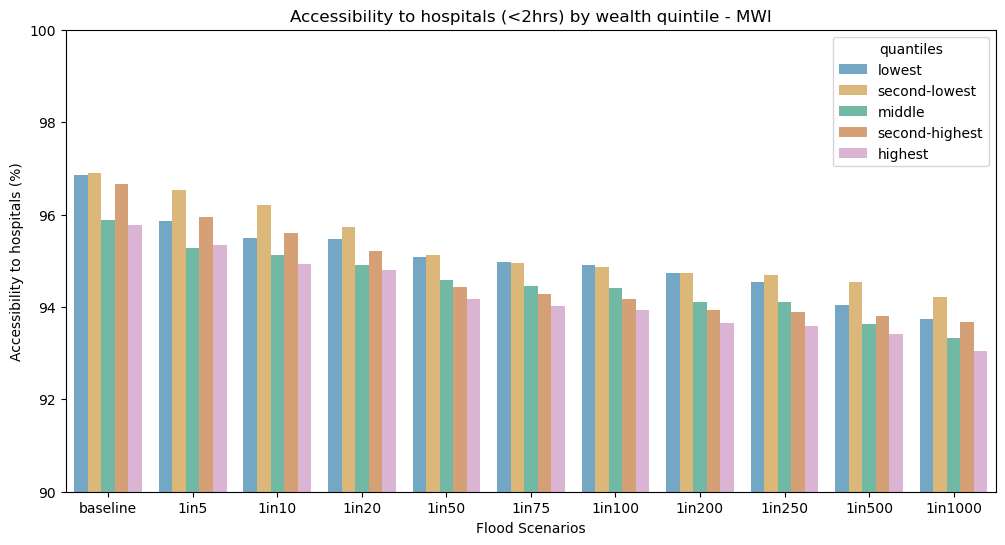

In [357]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Accessibility to hospitals (<2hrs) by wealth quintile - " + iso)
ax0.set_xticklabels(scen)
ax0.set_xlabel("Flood Scenarios")
ax0.set_ylabel("Accessibility to hospitals (%)")
ax0.set_ylim(90,100)
ax0.legend(loc='upper left', fontsize = 10, title = "RWI quantiles")
ax0 = sns.barplot(
    data=res_rwi_adm0_long, hue="quantiles",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)

In [500]:
res_rwi_adm1["hospital_pct_impact"] = (res_rwi_adm1["hospital_pct_1in1000"] - res_rwi_adm1["hospital_pct_baseline"])/res_rwi_adm1["hospital_pct_baseline"]

In [501]:
test = res_rwi_adm1.copy()
test = test[["ADM1", "quantiles", "hospital_pct_impact"]]

quant = pd.DataFrame(test["ADM1"].unique())
for q in test.quantiles.unique().to_list():
    quant["hospital_pct_impact_"+ q] = test[test["quantiles"] == q]["hospital_pct_impact"].values.round(3)*100
    
quant = quant.rename(columns = {quant.columns[0]:"ADM1"})
quant = quant.merge(right = adm1[["ADM1",'geometry']], on = "ADM1", how = "left")
quant = gpd.GeoDataFrame(quant, crs=epsg, geometry="geometry")
# quant = quant*100
quant.head(2)

,ADM1,hospital_pct_impact_lowest,hospital_pct_impact_second-lowest,hospital_pct_impact_middle,hospital_pct_impact_second-highest,hospital_pct_impact_highest,geometry
0,Balaka,0.0,-0.5,-2.1,-2.0,-1.5,"MULTIPOLYGON (((35.07923 -15.30382, 35.07925 -..."
1,Blantyre,-5.5,-2.1,0.0,-6.6,-2.1,"MULTIPOLYGON (((34.94884 -15.98430, 34.94793 -..."


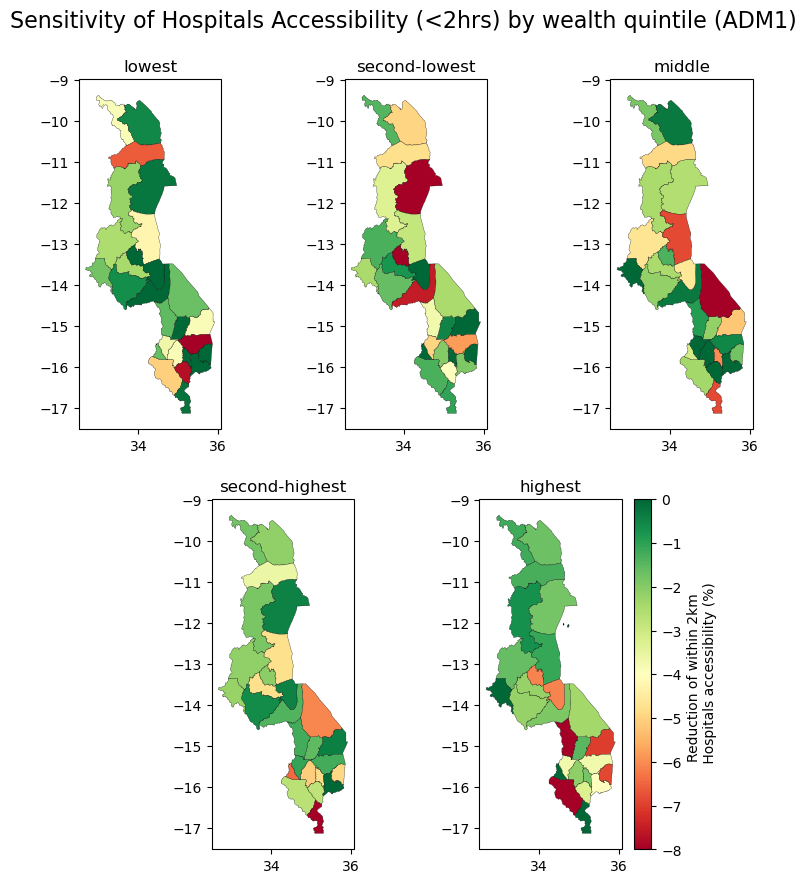

In [502]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (10,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 6)

fig.suptitle("Sensitivity of Hospitals Accessibility (<2hrs) by wealth quintile (ADM1)", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

for i, q in enumerate(quant.columns[1:6]):
    if i < 3:
        ax = fig.add_subplot(gs[0, 2 * i : 2 * i + 2], projection=projection)
    else:
        ax = fig.add_subplot(gs[1, 2 * i - 5 : 2 * i - 3], projection=projection)

    ax.set_title(q.split("_")[3])
    ax.get_xaxis().set_visible(True) # plt.axis('off')
    ax.get_yaxis().set_visible(True)
    
    cmap = "RdYlGn"

    if i == 4:
        quant.plot(
        ax=ax, column=q, cmap=cmap, legend=True,
        alpha=1, linewidth=0.2, edgecolor='black', 
        # scheme = "user defined", classification_kwds = {'bins': [-0.02,-0.04,-0.6,-0.08,-0.10,-0.12]},
        legend_kwds = {
            'label': "Reduction of within 2km \n Hospitals accessibility (%)",
            # "loc": "upper right",
            # "bbox_to_anchor": (2.7, 1), 
            # 'fontsize': 10,
            # 'fmt': "{:.0%}",
            # 'title_fontsize': 12
        }
    )
    else:
        quant.plot(
        ax=ax, column=q, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        # scheme = "naturalbreaks", classification_kwds = {'bins': [-0.02,-0.04,-0.6,-0.08,-0.10,-0.12]},
        legend_kwds = {
            'title': "Reduction of within 2km \n Hospitals accessibility (%)",
            "loc": "upper right",
            "bbox_to_anchor": (2.7, 1), 
            'fontsize': 10,
            'fmt': "{:.0%}",
            'title_fontsize': 12
        }
    )
        
    # ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


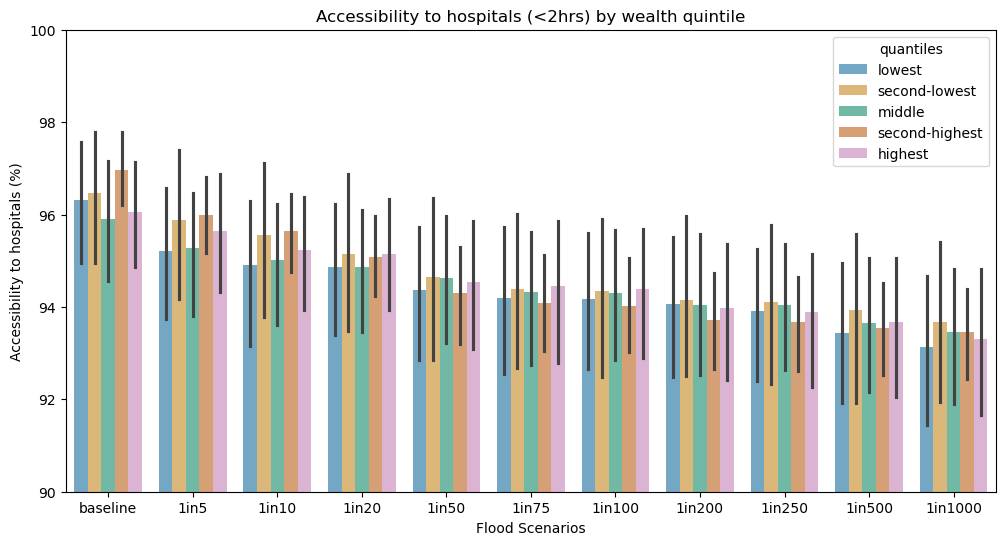

In [355]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Accessibility to hospitals (<2hrs) by wealth quintile")
ax0.set_xticklabels(scen)
ax0.set_xlabel("Flood Scenarios")
ax0.set_ylabel("Accessibility to hospitals (%)")
ax0.set_ylim(90,100)
ax0.legend(loc='upper left', fontsize = 10, title = "RWI quantiles")
ax0 = sns.barplot(
    data=res_rwi_adm1_long, hue="quantiles",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)